In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

# One-hot
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)
y_train_cifar = to_categorical(y_train_cifar, 10)
y_test_cifar = to_categorical(y_test_cifar, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
def compress_batch(images, k):
    shift = 8 - k
    return (images >> shift) << shift

In [ ]:
def preprocess_batch(images):
    images = images / 255.0
    if len(images.shape) == 3:  # MNIST
        images = np.expand_dims(images, -1)
    return images

In [ ]:
def build_mnist_model():
    return models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

def build_cifar_model():
    return models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

In [ ]:
def compute_metrics_batch(original, compressed, sample_size=500):
    idx = np.random.choice(len(original), sample_size, replace=False)

    mse_list, psnr_list, ssim_list = [], [], []

    for i in idx:
        o = original[i]
        c = compressed[i]

        mse = mean_squared_error(o.flatten(), c.flatten())
        psnr = 100 if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))

        ssim_val = ssim(
            o,
            c,
            channel_axis=-1 if len(o.shape)==3 else None,
            data_range=255
        )

        mse_list.append(mse)
        psnr_list.append(psnr)
        ssim_list.append(ssim_val)

    return np.mean(mse_list), np.mean(psnr_list), np.mean(ssim_list)

In [ ]:
print("Training ORIGINAL models...")

# MNIST
x_train_m = preprocess_batch(x_train_mnist)
x_test_m = preprocess_batch(x_test_mnist)

model_m = build_mnist_model()
model_m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_m.fit(x_train_m, y_train_mnist, epochs=5, batch_size=128, verbose=1)

_, mnist_orig_acc = model_m.evaluate(x_test_m, y_test_mnist)

# CIFAR
x_train_c = preprocess_batch(x_train_cifar)
x_test_c = preprocess_batch(x_test_cifar)

model_c = build_cifar_model()
model_c.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_c.fit(x_train_c, y_train_cifar, epochs=20, batch_size=128, verbose=1)

_, cifar_orig_acc = model_c.evaluate(x_test_c, y_test_cifar)

Training ORIGINAL models...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 100ms/step - accuracy: 0.9389 - loss: 0.2115
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 86ms/step - accuracy: 0.9827 - loss: 0.0561
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accuracy: 0.9879 - loss: 0.0394
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.9908 - loss: 0.0296
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9927 - loss: 0.0234
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9894 - loss: 0.0297
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 62s 153ms/step - accuracy: 0.4201 - loss: 1.5966
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 150ms/step - accuracy: 0.5620 - loss: 1.2343
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 148ms/step - accuracy: 0.6302 - loss: 1.0591
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 148ms/step - accuracy: 0.6722 - loss: 0.9399
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 148ms/step - accuracy: 0.7019 - loss: 0.8562
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 57s

In [ ]:
bit_levels = [7,6,5,4,3,2,1]
results = []

for k in bit_levels:
    print(f"\nProcessing {k}-bit...")

    # Compress FULL dataset
    mnist_comp = compress_batch(x_train_mnist, k)
    cifar_comp = compress_batch(x_train_cifar, k)

    # Metrics
    _, mnist_psnr, mnist_ssim = compute_metrics_batch(x_train_mnist, mnist_comp)
    _, cifar_psnr, cifar_ssim = compute_metrics_batch(x_train_cifar, cifar_comp)

    # Train MNIST
    x_train_m = preprocess_batch(mnist_comp)
    x_test_m = preprocess_batch(x_test_mnist)

    model_m = build_mnist_model()
    model_m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model_m.fit(x_train_m, y_train_mnist, epochs=5, batch_size=128, verbose=1)

    _, mnist_acc = model_m.evaluate(x_test_m, y_test_mnist)

    # Train CIFAR
    x_train_c = preprocess_batch(cifar_comp)
    x_test_c = preprocess_batch(x_test_cifar)

    model_c = build_cifar_model()
    model_c.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model_c.fit(x_train_c, y_train_cifar, epochs=20, batch_size=128, verbose=1)

    _, cifar_acc = model_c.evaluate(x_test_c, y_test_cifar)

    reduction = (1 - k/8) * 100

    results.append({
        "bit": k,
        "mnist_acc": mnist_acc,
        "cifar_acc": cifar_acc,
        "mnist_psnr": mnist_psnr,
        "cifar_psnr": cifar_psnr,
        "mnist_ssim": mnist_ssim,
        "cifar_ssim": cifar_ssim,
        "reduction": reduction
    })


Processing 7-bit...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.9372 - loss: 0.2149
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9821 - loss: 0.0580
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9880 - loss: 0.0398
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9911 - loss: 0.0299
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.9928 - loss: 0.0237
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9914 - loss: 0.0264
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 61s 150ms/step - accuracy: 0.4183 - loss: 1.5954
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 152ms/step - accuracy: 0.5651 - loss: 1.2337
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 149ms/step - accuracy: 0.6260 - loss: 1.0704
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 151ms/step - accuracy: 0.6630 - loss: 0.9628
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 148ms/step - accuracy: 0.6936 - loss: 0.8822
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.9403 - loss: 0.2051
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9814 - loss: 0.0608
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 0.9872 - loss: 0.0414
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9901 - loss: 0.0316
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9925 - loss: 0.0242
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9886 - loss: 0.0329
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 156ms/step - accuracy: 0.4174 - loss: 1.6011
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 149ms/step - accuracy: 0.5618 - loss: 1.2253
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 154ms/step - accuracy: 0.6247 - loss: 1.0650
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 152ms/step - accuracy: 0.6676 - loss: 0.9458
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 152ms/step - accuracy: 0.6949 - loss: 0.8675
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 

...

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.9395 - loss: 0.2083
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9824 - loss: 0.0559
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.9878 - loss: 0.0395
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9907 - loss: 0.0302
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 0.9922 - loss: 0.0243
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9895 - loss: 0.0355
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 156ms/step - accuracy: 0.4282 - loss: 1.5721
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 149ms/step - accuracy: 0.5740 - loss: 1.2006
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.6333 - loss: 1.0433
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 149ms/step - accuracy: 0.6728 - loss: 0.9368
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 151ms/step - accuracy: 0.7030 - loss: 0.8508
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.9328 - loss: 0.2265
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 90ms/step - accuracy: 0.9819 - loss: 0.0585
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9872 - loss: 0.0400
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.9902 - loss: 0.0316
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.9923 - loss: 0.0247
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9893 - loss: 0.0329
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 67s 160ms/step - accuracy: 0.4276 - loss: 1.5583
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 148ms/step - accuracy: 0.5660 - loss: 1.2136
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 148ms/step - accuracy: 0.6257 - loss: 1.0609
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 149ms/step - accuracy: 0.6639 - loss: 0.9545
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 148ms/step - accuracy: 0.6904 - loss: 0.8778
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.9334 - loss: 0.2347
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.9794 - loss: 0.0667
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 88ms/step - accuracy: 0.9854 - loss: 0.0470
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.9878 - loss: 0.0366
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 87ms/step - accuracy: 0.9916 - loss: 0.0274
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9851 - loss: 0.0602
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 62s 153ms/step - accuracy: 0.3963 - loss: 1.6597
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 145ms/step - accuracy: 0.5147 - loss: 1.3497
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 144ms/step - accuracy: 0.5740 - loss: 1.1951
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 147ms/step - accuracy: 0.6144 - loss: 1.0896
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 148ms/step - accuracy: 0.6434 - loss: 1.0085
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 

In [ ]:
results.insert(0, {
    "bit": 8,
    "mnist_acc": mnist_orig_acc,
    "cifar_acc": cifar_orig_acc,
    "mnist_psnr": float('inf'),
    "cifar_psnr": float('inf'),
    "mnist_ssim": 1.0,
    "cifar_ssim": 1.0,
    "reduction": 0.0
})

print("\nFINAL RESULTS:\n")
print("Bit | MNIST Acc | CIFAR Acc | PSNR(M) | PSNR(C) | SSIM(M) | SSIM(C) | Reduction %")
print("-"*100)

for r in results:
    print(f"{r['bit']}   | {r['mnist_acc']:.4f} | {r['cifar_acc']:.4f} | "
          f"{r['mnist_psnr']:.2f} | {r['cifar_psnr']:.2f} | "
          f"{r['mnist_ssim']:.4f} | {r['cifar_ssim']:.4f} | "
          f"{r['reduction']:.2f}%")


FINAL RESULTS:

Bit | MNIST Acc | CIFAR Acc | PSNR(M) | PSNR(C) | SSIM(M) | SSIM(C) | Reduction %
----------------------------------------------------------------------------------------------------
8   | 0.9894 | 0.7210 | inf | inf | 1.0000 | 1.0000 | 0.00%
7   | 0.9914 | 0.7110 | 58.50 | 51.10 | 1.0000 | 0.9996 | 12.50%
6   | 0.9886 | 0.7118 | 50.65 | 42.66 | 0.9999 | 0.9976 | 25.00%
5   | 0.9907 | 0.7095 | 42.30 | 35.66 | 0.9992 | 0.9897 | 37.50%
4   | 0.9898 | 0.7137 | 35.05 | 29.18 | 0.9962 | 0.9678 | 50.00%
3   | 0.9895 | 0.6982 | 28.44 | 22.87 | 0.9827 | 0.8951 | 62.50%
2   | 0.9893 | 0.6548 | 22.12 | 16.76 | 0.9295 | 0.7226 | 75.00%
1   | 0.9851 | 0.4672 | 15.91 | 10.93 | 0.7219 | 0.3693 | 87.50%


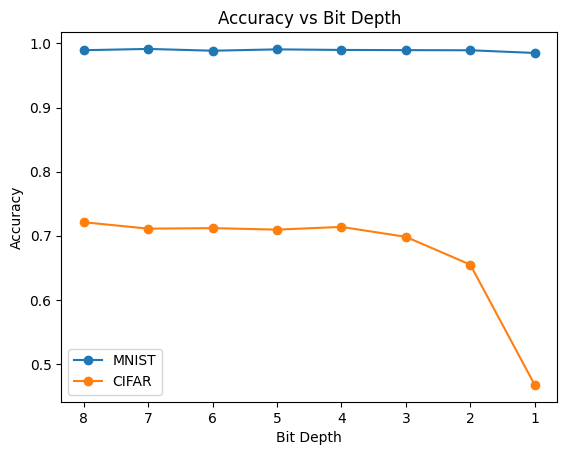

In [ ]:
bits = [r["bit"] for r in results]
mnist_acc = [r["mnist_acc"] for r in results]
cifar_acc = [r["cifar_acc"] for r in results]

plt.figure()
plt.plot(bits, mnist_acc, marker='o', label='MNIST')
plt.plot(bits, cifar_acc, marker='o', label='CIFAR')
plt.xlabel("Bit Depth")
plt.ylabel("Accuracy")
plt.gca().invert_xaxis()
plt.legend()
plt.title("Accuracy vs Bit Depth")
plt.show()

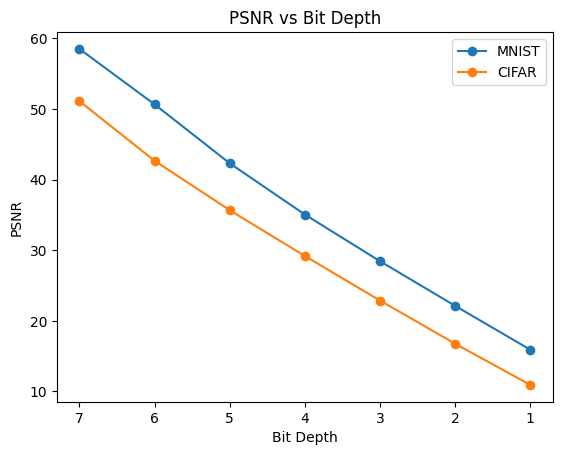

In [ ]:
bits = [r["bit"] for r in results]

mnist_psnr = [r["mnist_psnr"] for r in results]
cifar_psnr = [r["cifar_psnr"] for r in results]

plt.figure()
plt.plot(bits, mnist_psnr, marker='o', label='MNIST')
plt.plot(bits, cifar_psnr, marker='o', label='CIFAR')
plt.xlabel("Bit Depth")
plt.ylabel("PSNR")
plt.gca().invert_xaxis()
plt.legend()
plt.title("PSNR vs Bit Depth")
plt.show()

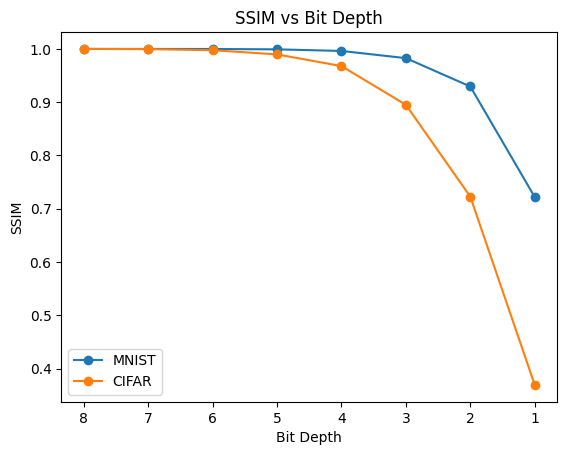

In [ ]:
mnist_ssim = [r["mnist_ssim"] for r in results]
cifar_ssim = [r["cifar_ssim"] for r in results]

plt.figure()
plt.plot(bits, mnist_ssim, marker='o', label='MNIST')
plt.plot(bits, cifar_ssim, marker='o', label='CIFAR')
plt.xlabel("Bit Depth")
plt.ylabel("SSIM")
plt.gca().invert_xaxis()
plt.legend()
plt.title("SSIM vs Bit Depth")
plt.show()

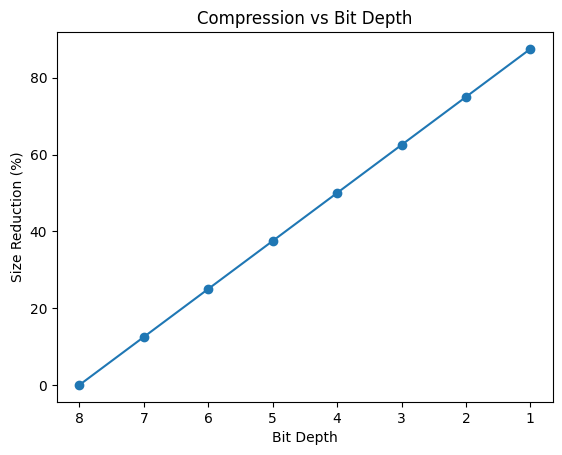

In [ ]:
reduction = [r["reduction"] for r in results]

plt.figure()
plt.plot(bits, reduction, marker='o')
plt.xlabel("Bit Depth")
plt.ylabel("Size Reduction (%)")
plt.gca().invert_xaxis()
plt.title("Compression vs Bit Depth")
plt.show()